Importing all libraries 

In [321]:
from sklearn import preprocessing, tree, metrics, model_selection, ensemble, linear_model, compose
from sklearn.pipeline import Pipeline
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import seaborn as sns
import numpy as np
import xgboost

### Step 2: Dataset Loading & Exploratory Data Analysis

------------------------------------------------------------------------------------------------------------------------------------

#### 2.1 Load & Understand the Dataset


#### Load train.csv using pandas. Print .shape, .info(), and .describe().

In [255]:
df = pd.read_csv("train.csv")
df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [256]:
print("Info of Dataset\n", df.info(), "\n")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

Shape of Dataset

In [257]:
print("Shape of Dataset\n", df.shape, "\n")

Shape of Dataset
 (1460, 81) 



In [258]:
print("Describe of Dataset\n", df.describe(), "\n")

Describe of Dataset
                 Id   MSSubClass  LotFrontage        LotArea  OverallQual  \
count  1460.000000  1460.000000  1201.000000    1460.000000  1460.000000   
mean    730.500000    56.897260    70.049958   10516.828082     6.099315   
std     421.610009    42.300571    24.284752    9981.264932     1.382997   
min       1.000000    20.000000    21.000000    1300.000000     1.000000   
25%     365.750000    20.000000    59.000000    7553.500000     5.000000   
50%     730.500000    50.000000    69.000000    9478.500000     6.000000   
75%    1095.250000    70.000000    80.000000   11601.500000     7.000000   
max    1460.000000   190.000000   313.000000  215245.000000    10.000000   

       OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1  ...  \
count  1460.000000  1460.000000   1460.000000  1452.000000  1460.000000  ...   
mean      5.575342  1971.267808   1984.865753   103.685262   443.639726  ...   
std       1.112799    30.202904     20.645407   181.06

#### Identify: (a) how many numerical columns, (b) how many categorical columns, (c) how many columns have missing values.

In [259]:
numeric_df = df.select_dtypes(include='number')
categorical_df = df.select_dtypes(include='object')
missing_values = df.isna().sum()

print("Numeric Columns\n", numeric_df.columns, "\n")
print("Categorical Columns\n", categorical_df.columns, "\n")
print("Missing Values\n", missing_values, "\n")

Numeric Columns
 Index(['Id', 'MSSubClass', 'LotFrontage', 'LotArea', 'OverallQual',
       'OverallCond', 'YearBuilt', 'YearRemodAdd', 'MasVnrArea', 'BsmtFinSF1',
       'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF',
       'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'FullBath',
       'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'TotRmsAbvGrd',
       'Fireplaces', 'GarageYrBlt', 'GarageCars', 'GarageArea', 'WoodDeckSF',
       'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea',
       'MiscVal', 'MoSold', 'YrSold', 'SalePrice'],
      dtype='object') 

Categorical Columns
 Index(['MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
       'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2',
       'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
       'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation',
       'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinTyp

#### Plot a histogram and Q-Q plot of the target variable SalePrice. Is it normally distributed? Apply log1p transformation and re-plot.

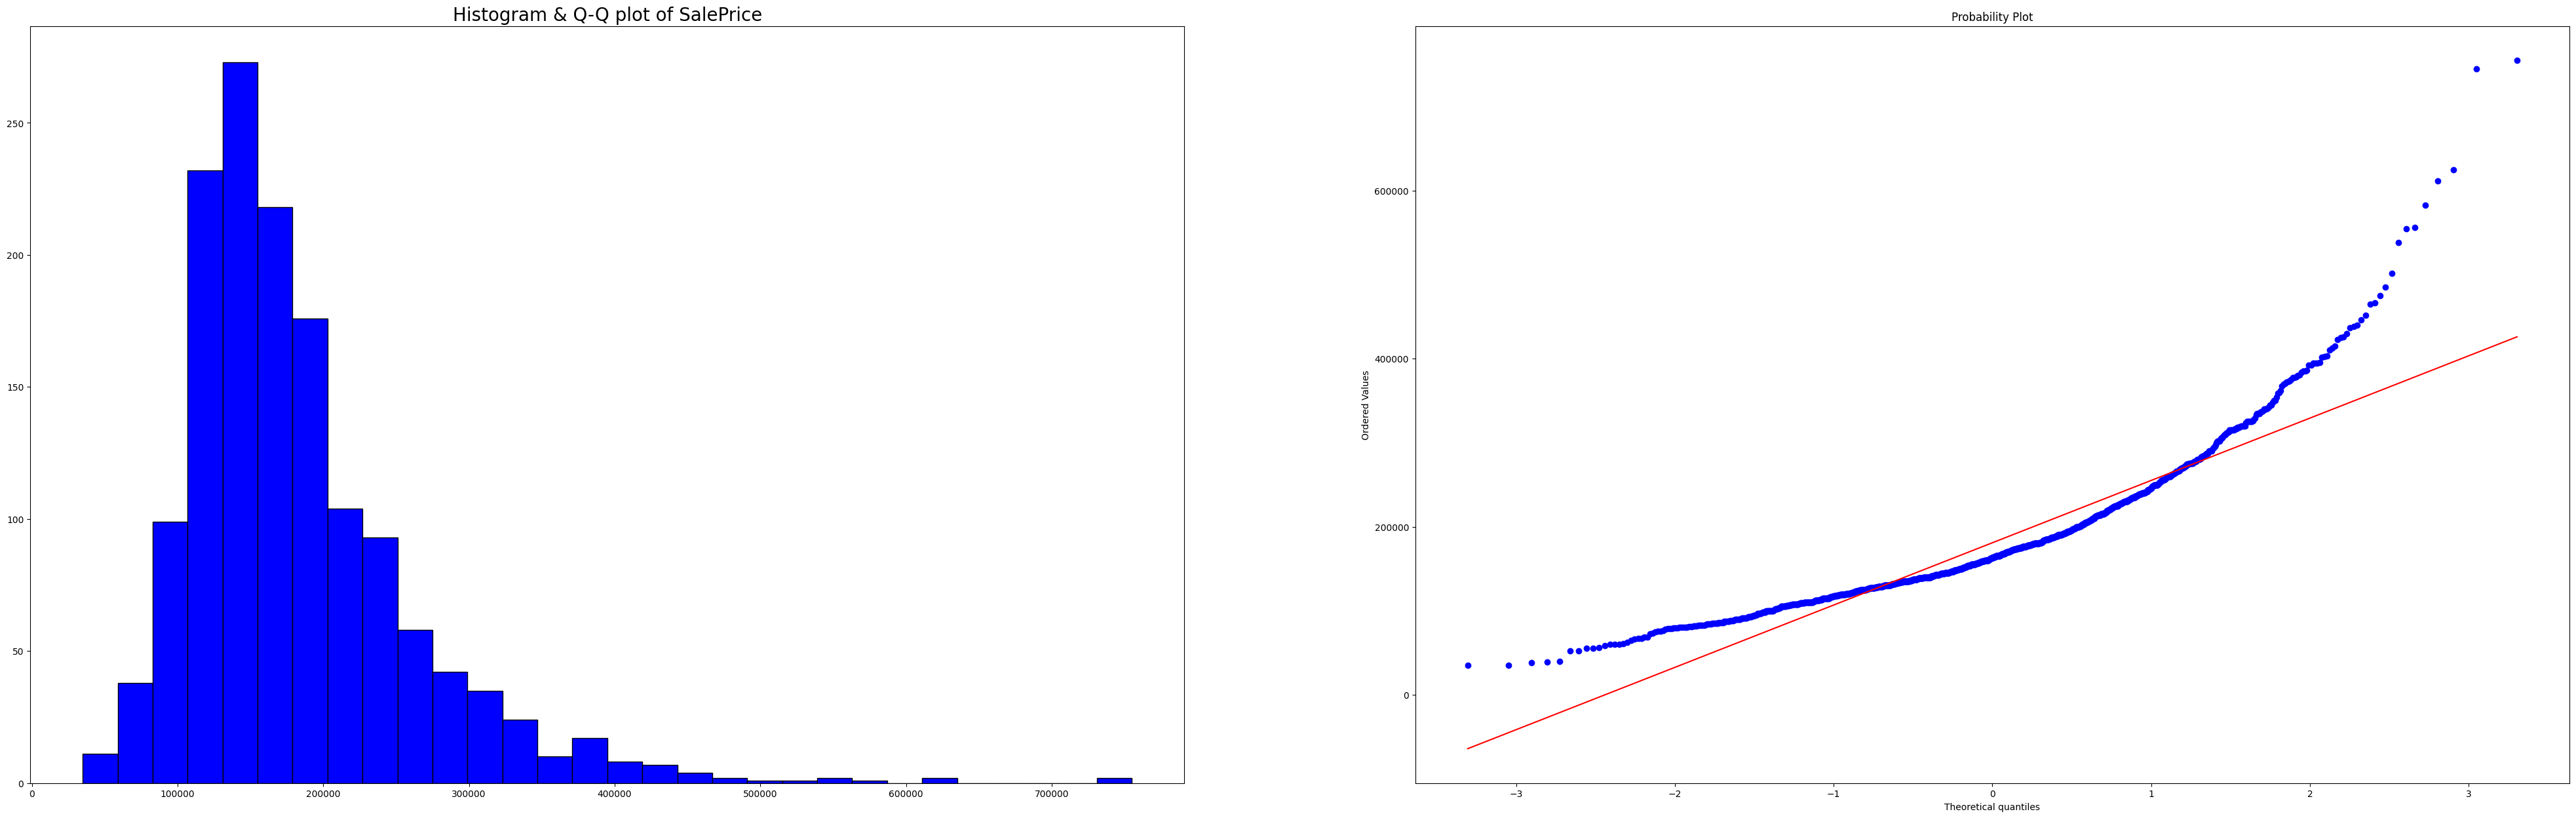

In [260]:
plt.figure(figsize=(50, 15))
plt.subplot(1, 2, 1)
plt.title('Histogram & Q-Q plot of SalePrice', fontsize=20)
plt.hist(df['SalePrice'], bins=30, color='blue', edgecolor='black')
stats.probplot(df['SalePrice'], dist="norm", plot=plt.subplot(1, 2, 2))
plt.show()


------------------------------------------------------------------------------------------------------------------------------------

#### 2.2 Univariate Analysis

#### Plot histograms for all numerical features. Identify the top 5 most skewed columns.

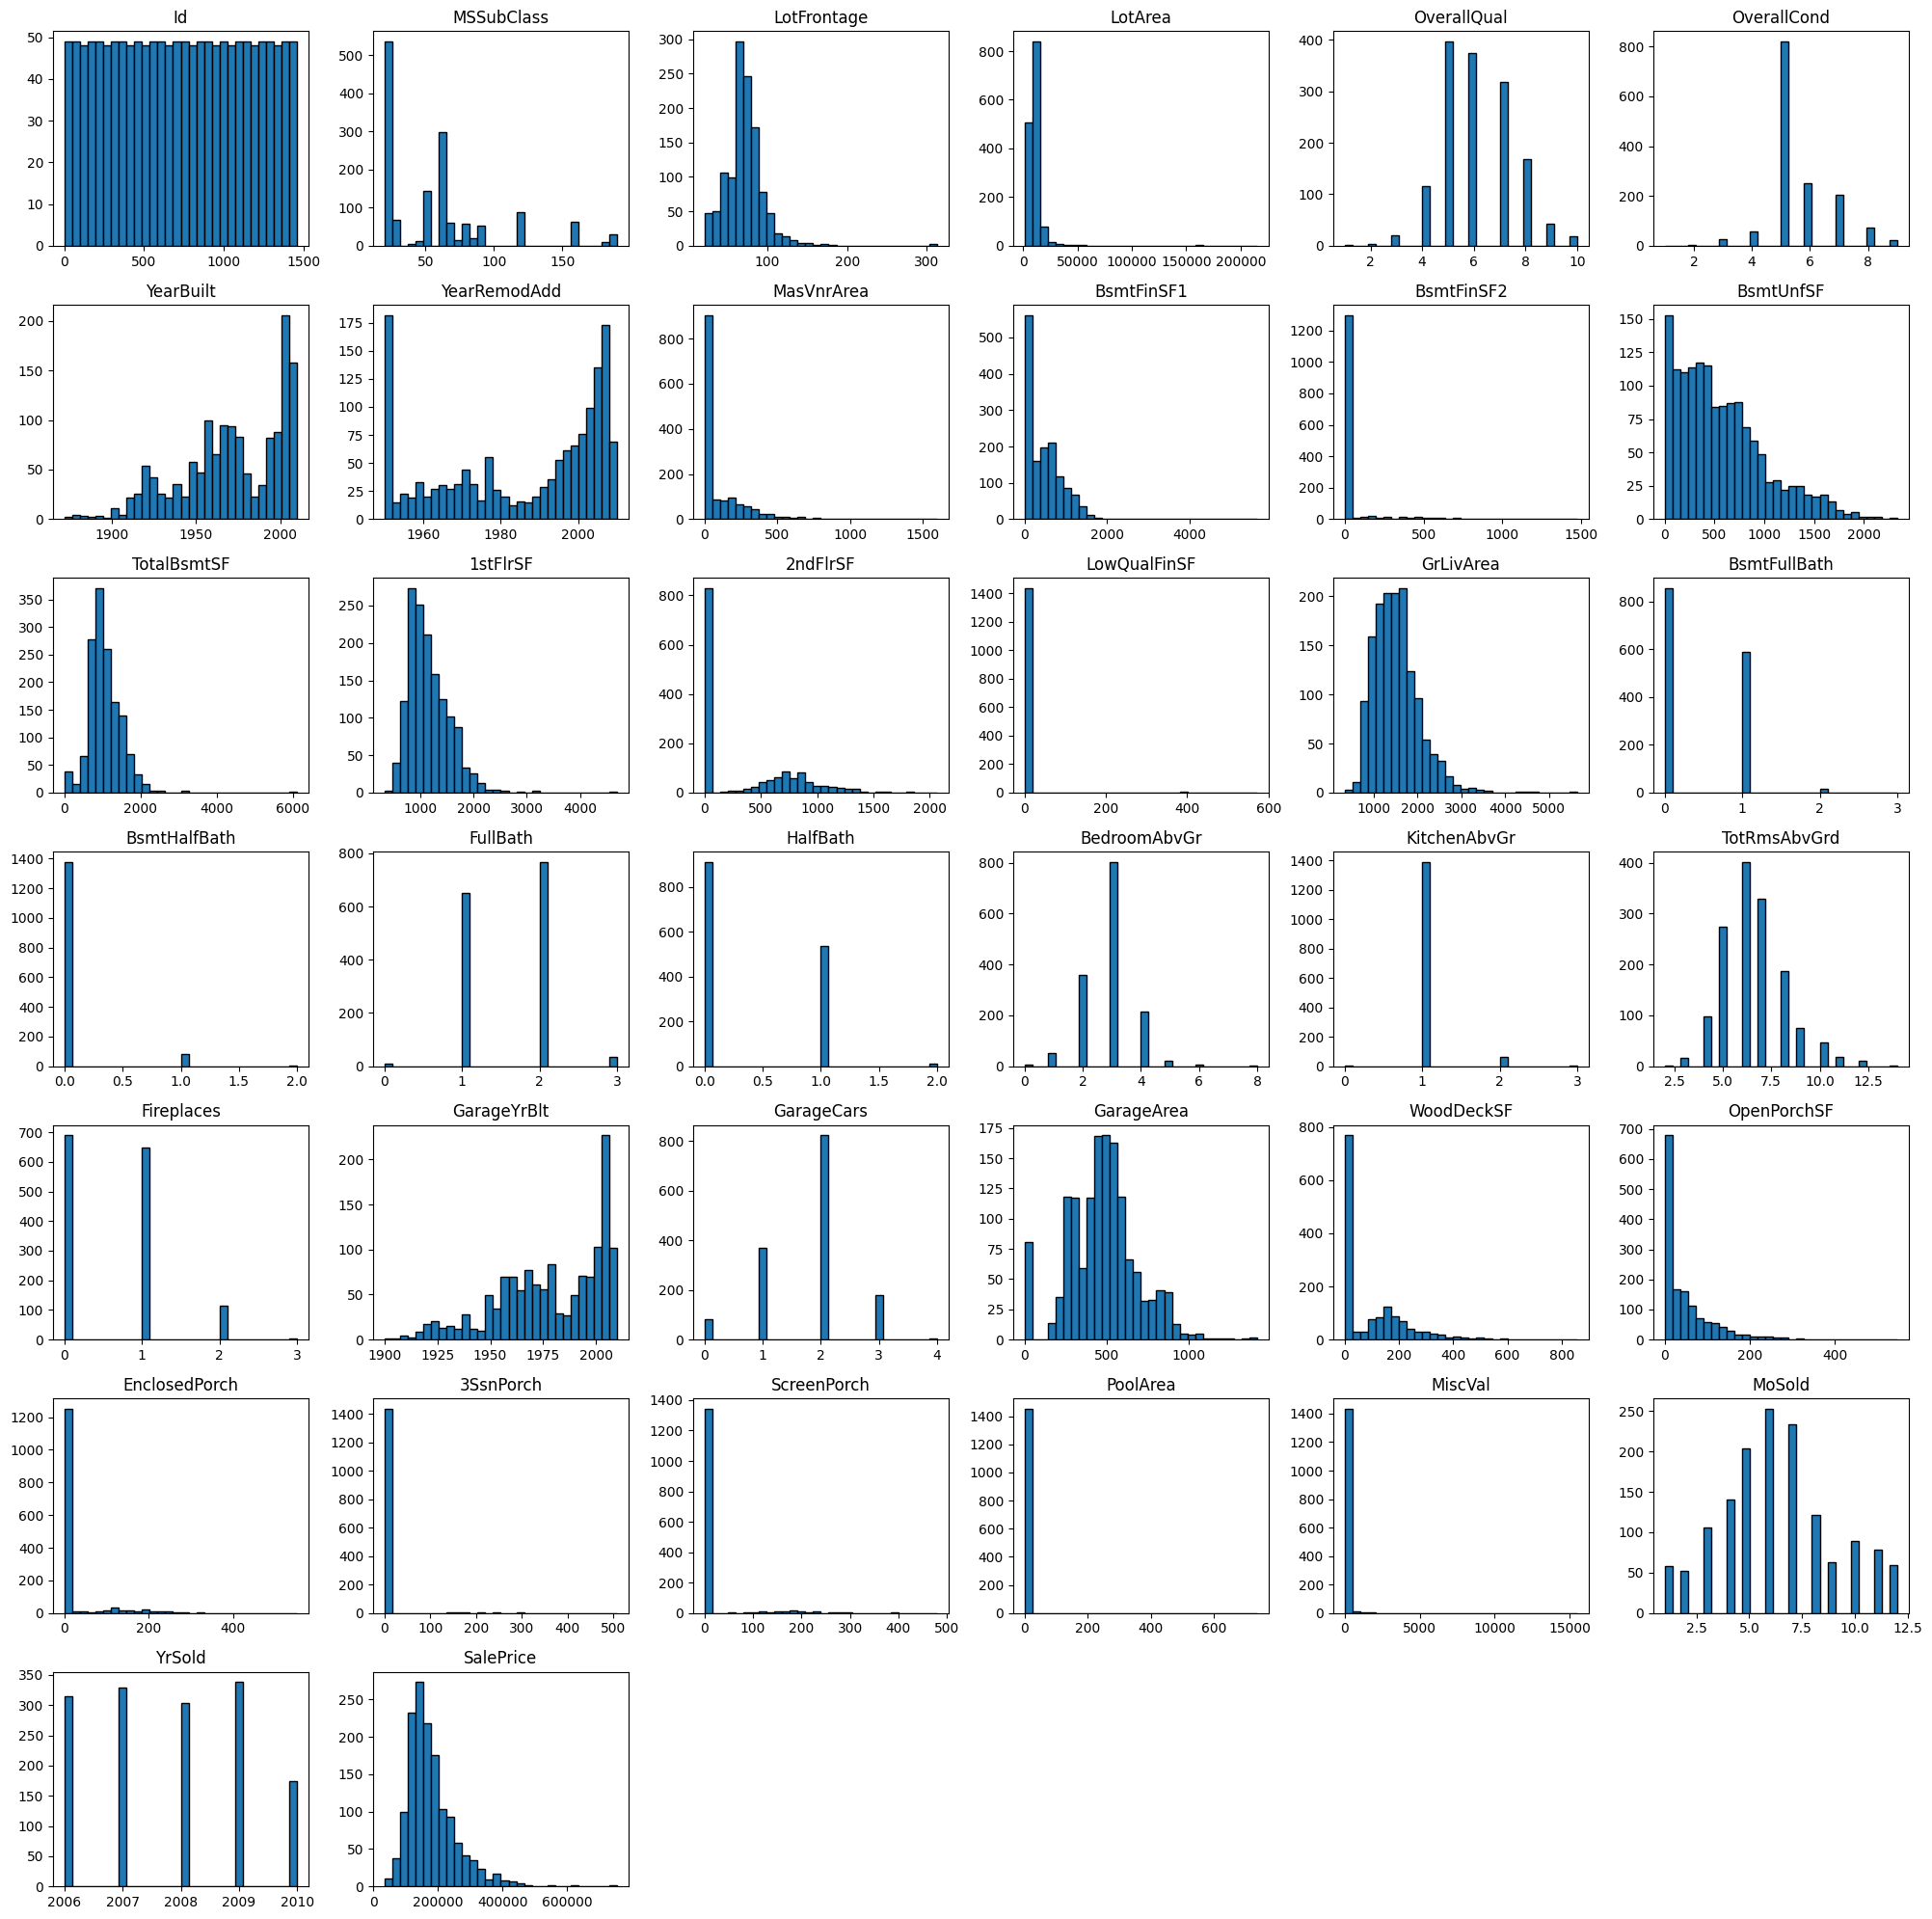

In [261]:

numeric_df.hist(figsize=(20, 20), bins=30, edgecolor='black', grid=False)
plt.tight_layout()
plt.show()


In [262]:
skewness = numeric_df.skew()
top_5_skewed = skewness.abs().sort_values(ascending=False).head(5)
print("Top 5 most skewed columns:")
print(top_5_skewed)

Top 5 most skewed columns:
MiscVal         24.476794
PoolArea        14.828374
LotArea         12.207688
3SsnPorch       10.304342
LowQualFinSF     9.011341
dtype: float64


#### Plot countplots for high-impact categorical columns: Neighborhood, BldgType, HouseStyle.

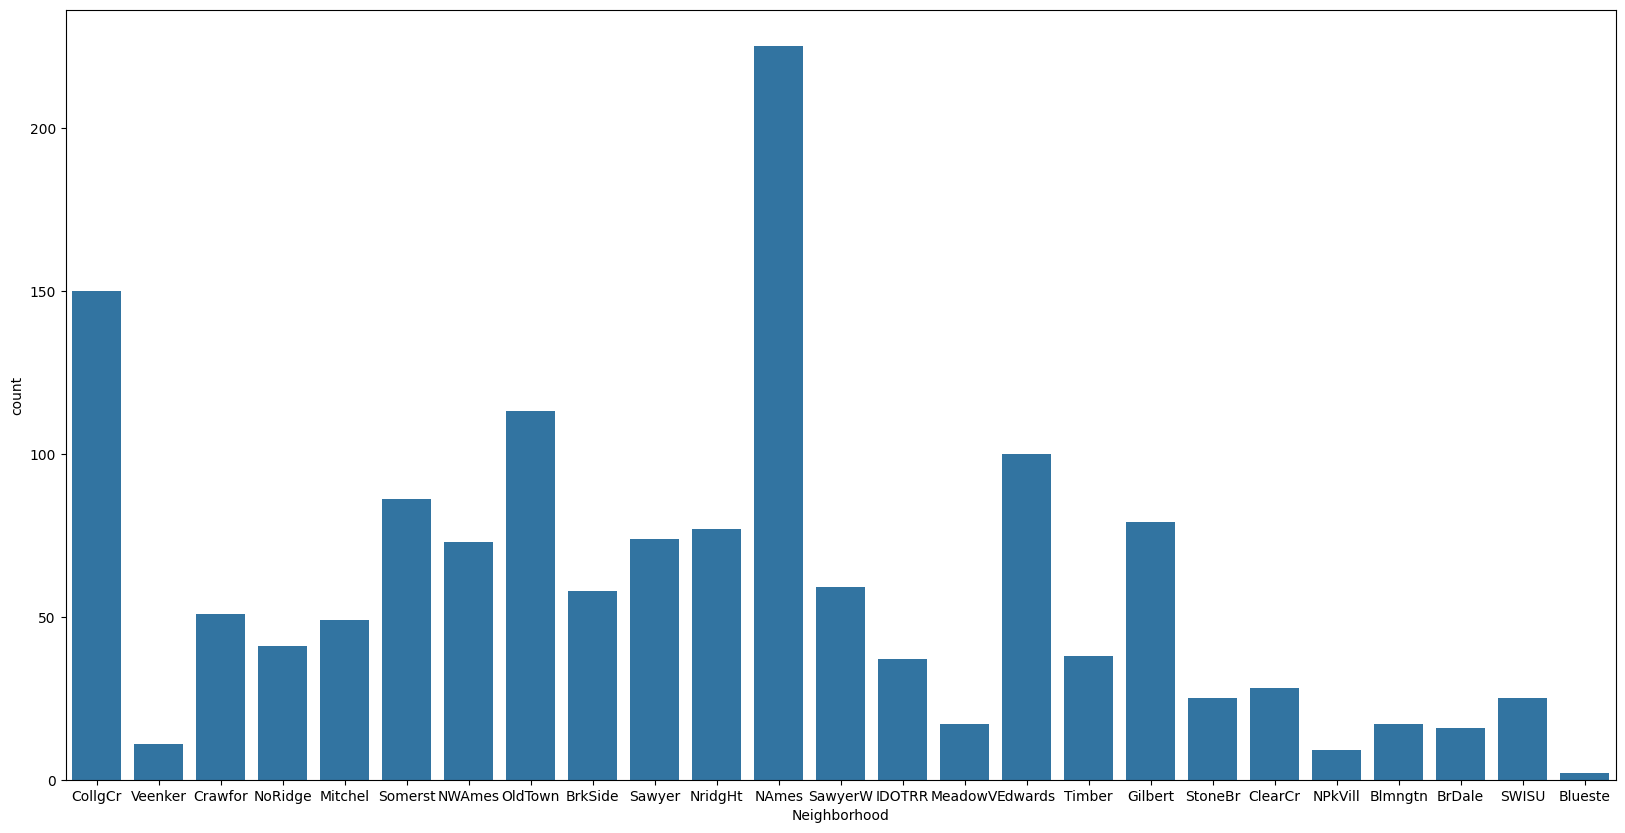

In [263]:
high_impact_featurers = df[['Neighborhood', 'BldgType', 'HouseStyle']]
plt.figure(figsize=(20, 10))
sns.countplot(x='Neighborhood', data=high_impact_featurers)
plt.show()


------------------------------------------------------------------------------------------------------------------------------------

#### 2.3 Bivariate Analysis

#### Plot a heatmap of the top 15 features most correlated with SalePrice

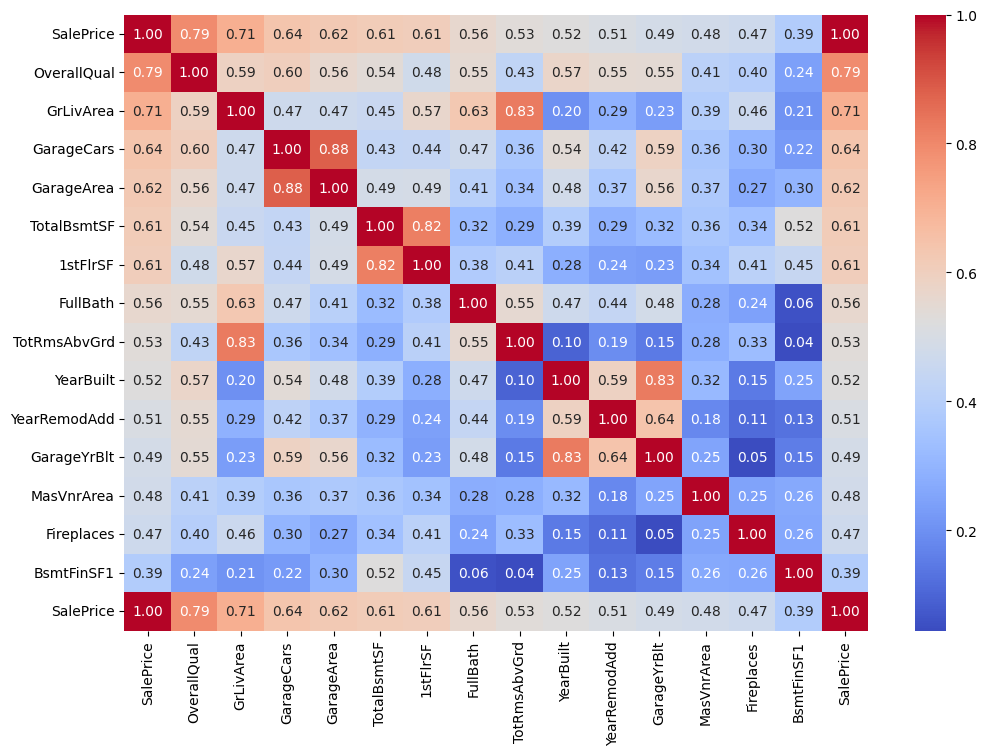

In [264]:
correlation = df.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
top_15 = correlation.head(15)
top_15_features = top_15.index
corr_matrix = df[top_15_features.tolist() + ['SalePrice']].corr()
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.show()


#### Scatter plots: GrLivArea vs SalePrice, TotalBsmtSF vs SalePrice, GarageArea vs SalePrice.


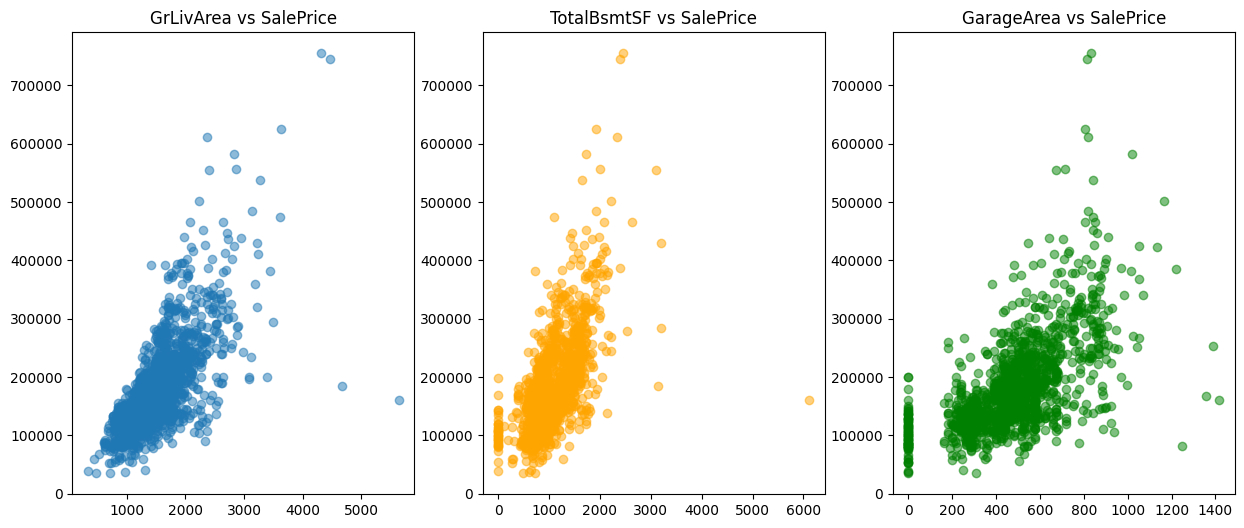

In [265]:
plt.figure(figsize=(15, 6))
plt.subplot(1, 3, 1)
plt.title('GrLivArea vs SalePrice')
plt.scatter(df['GrLivArea'], df['SalePrice'], alpha=0.5)
plt.subplot(1, 3, 2)
plt.title('TotalBsmtSF vs SalePrice')
plt.scatter(df['TotalBsmtSF'], df['SalePrice'], alpha=0.5, color='orange')
plt.subplot(1, 3, 3)
plt.title('GarageArea vs SalePrice')
plt.scatter(df['GarageArea'], df['SalePrice'], alpha=0.5, color='green')
plt.show()

#### Boxplots: OverallQual vs SalePrice, Neighborhood vs SalePrice (which neighborhood is the priciest?).

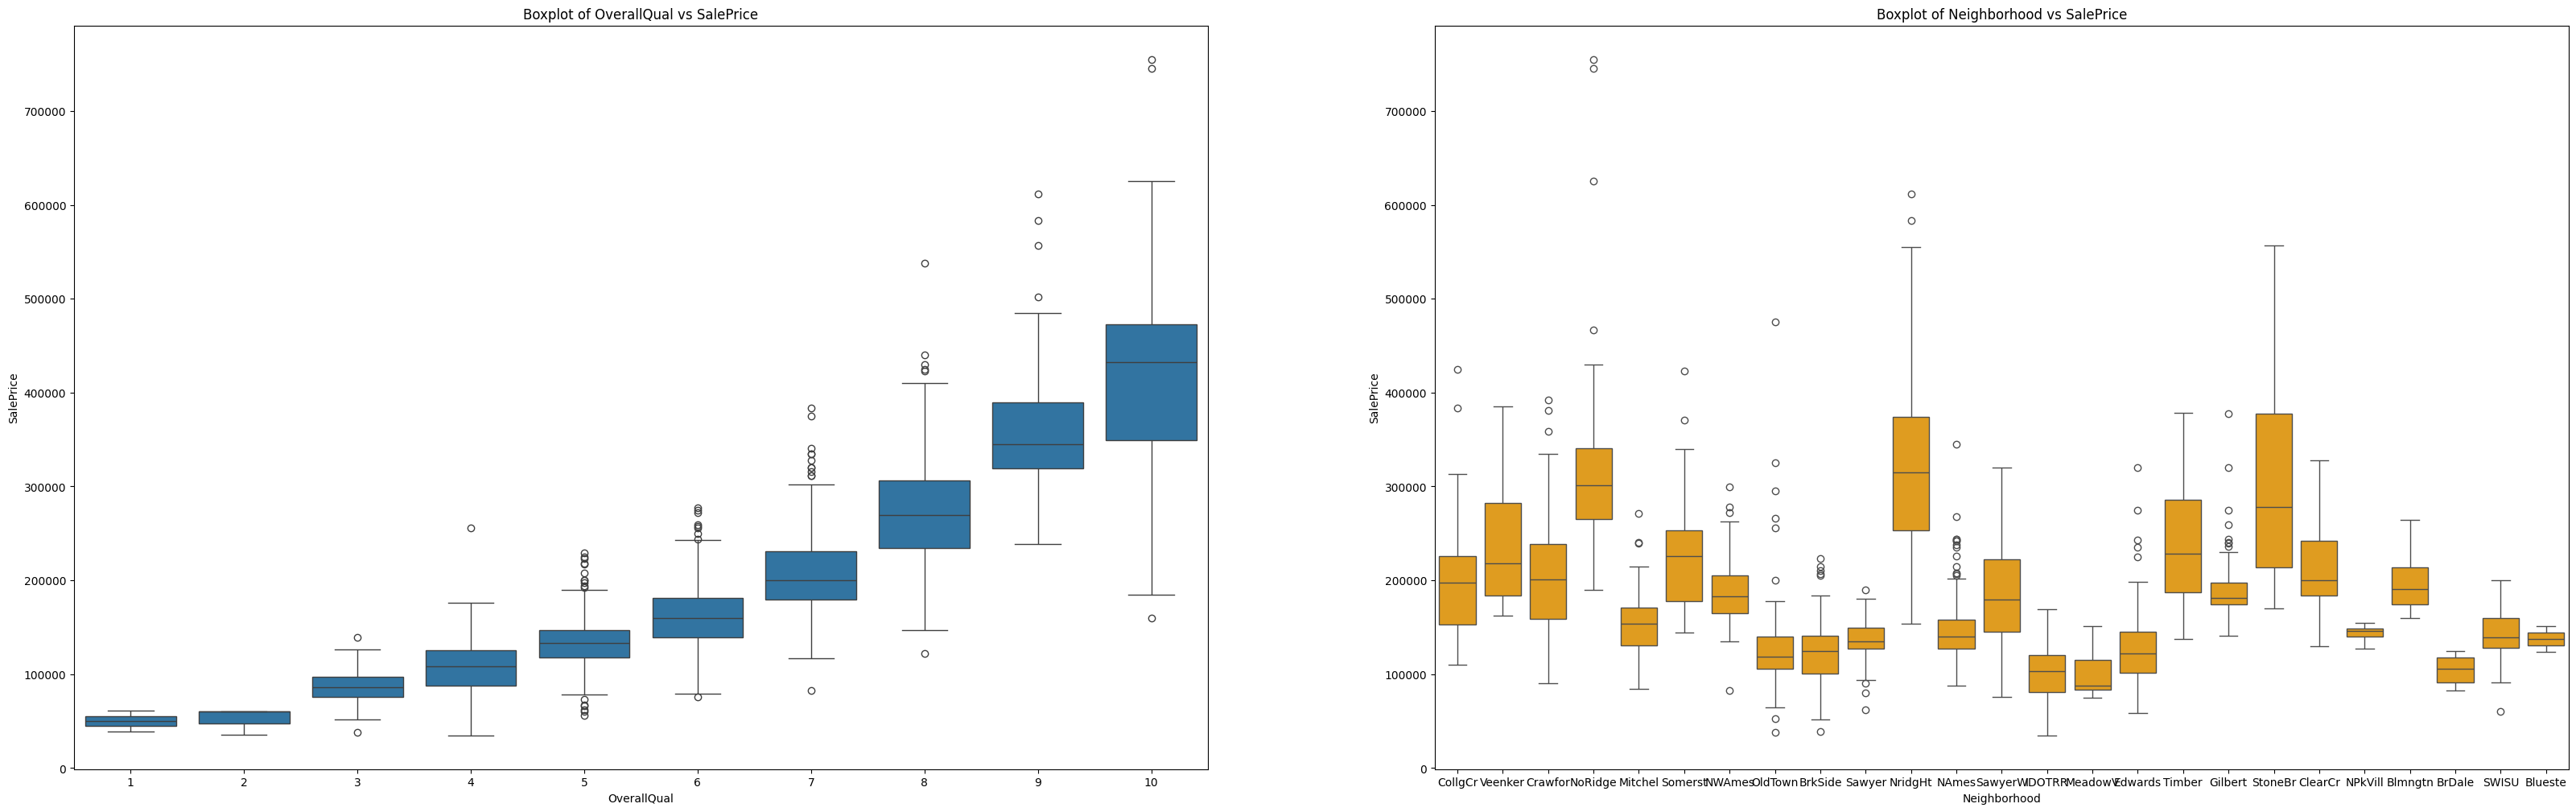

In [266]:
plt.figure(figsize=(40, 12))
plt.subplot(1, 2, 1)
plt.title('Boxplot of OverallQual vs SalePrice')
sns.boxplot(x=df['OverallQual'], y=df['SalePrice'])
plt.subplot(1, 2, 2)
plt.title('Boxplot of Neighborhood vs SalePrice')
sns.boxplot(x=df['Neighborhood'], y=df['SalePrice'], color='orange')
plt.show()

#### Identify and flag any outliers visible in GrLivArea vs SalePrice (hint: two extreme points exist).

Ans : There are 2 clear outliers where GrLivArea > 4000 but SalePrice < $300,000

------------------------------------------------------------------------------------------------------------------------------------

### Step 3: Data Preprocessing & Feature Engineering


------------------------------------------------------------------------------------------------------------------------------------

#### 3.1 Handle Missing Values

#### Report all columns with missing values and their missing %.

In [267]:
print(df.isna().sum(), "\n")
print(df.isna().mean()*100)

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64 

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
                   ...    
MoSold            0.000000
YrSold            0.000000
SaleType          0.000000
SaleCondition     0.000000
SalePrice         0.000000
Length: 81, dtype: float64


#### For categorical columns where NaN means 'None' (e.g., PoolQC, Fence, GarageType) — fill with 'None'.


In [268]:
categorical_df.fillna('None', inplace=True)

#### For numerical columns where NaN means 0 (e.g., GarageArea, BsmtFinSF1) — fill with 0

In [269]:
numeric_df.fillna(0, inplace=True)

#### For remaining numerical columns — fill with median.

In [270]:
numeric_df.fillna(numeric_df.median(), inplace=True)

Drop columns with >80% missing values

Ans : there are no columns less than 80% missing values

------------------------------------------------------------------------------------------------------------------------------------

#### 3.2 Outlier Removal

#### Remove the 2 outlier rows in GrLivArea where GrLivArea > 4000 and SalePrice < 300,000.


In [271]:
df.drop(df[(df['GrLivArea'] > 4000) & (df['SalePrice'] < 300000)].index, inplace=True)

Briefly explain why keeping these outliers would harm a linear model.

Ans : These outliers can pull the regression line away from the normal data. which can affect the model's prediction accuracy.

#### 3.3 Feature Engineering

#### Create TotalSF = TotalBsmtSF + 1stFlrSF + 2ndFlrSF (total usable area)

In [272]:
df['TotalSF'] = df['TotalBsmtSF'] + df['1stFlrSF'] + df['2ndFlrSF']

#### Create HouseAge = YrSold - YearBuilt.


In [273]:
df['HouseAge'] = df['YrSold'] - df['YearBuilt']

##### Create RemodAge = YrSold - YearRemodAdd.


In [274]:
df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']

#### Create HasGarage = 1 if GarageArea > 0 else 0.

In [275]:
df['HasGarage'] = df['GarageArea'].apply(lambda x: 1 if x > 0 else 0)

#### Create HasPool = 1 if PoolArea > 0 else 0.

In [276]:
df['HasPool'] = df['PoolArea'].apply(lambda x: 1 if x > 0 else 0)

#### 3.4 Encoding & Scaling

#### Apply Ordinal Encoding to quality/condition columns: ExterQual, KitchenQual, BsmtQual, FireplaceQu (map: Po→1, Fa→2, TA→3, Gd→4, Ex→5, None→0).


In [277]:
ordinalencoder_columns = [
    'ExterQual',
    'KitchenQual',
    'BsmtQual',
    'FireplaceQu'
]

ordinal=preprocessing.OrdinalEncoder()
df[ordinalencoder_columns] = ordinal.fit_transform(df[ordinalencoder_columns])

#### Apply One-Hot Encoding to nominal categoricals with ≤10 unique values (e.g., BldgType, HouseStyle, SaleCondition).

In [278]:
unique_categorical=categorical_df.columns[categorical_df.nunique().sort_values()<=10]
one_hot = preprocessing.OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoded = one_hot.fit_transform(df[unique_categorical])

#### Drop or label-encode high-cardinality columns (Neighborhood: use mean-target encoding or label encode)

In [279]:
label = preprocessing.LabelEncoder()
df['Neighborhood']= label.fit_transform(df['Neighborhood'])

#### Apply log1p transformation to skewed numerical features (skewness > 0.75).

In [280]:
num_skew=numeric_df.skew().sort_values(ascending=False)>0.75
skewed_columns = num_skew[num_skew].index
np.log1p(df[skewed_columns], out=df[skewed_columns])

C:\Users\Admin\AppData\Local\Temp\ipykernel_2612\1559916596.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  np.log1p(df[skewed_columns], out=df[skewed_columns])
C:\Users\Admin\AppData\Local\Temp\ipykernel_2612\1559916596.py:3: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise in a future error of pandas. Value '0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
1455    0.000000
1456    0.000000
1457    7.824446
1458    0.000000
1459    0.000000
Name: MiscVal, Length: 1458, dtype: float64' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  np.log1p(df[skewed_columns], out=df[skewed_columns])
C:\Users\Admin\AppData\Local\Temp

,MiscVal,PoolArea,LotArea,3SsnPorch,LowQualFinSF,KitchenAbvGr,BsmtFinSF2,ScreenPorch,BsmtHalfBath,EnclosedPorch,...,OpenPorchSF,SalePrice,BsmtFinSF1,WoodDeckSF,TotalBsmtSF,MSSubClass,1stFlrSF,GrLivArea,BsmtUnfSF,2ndFlrSF
0,0.000000,0.0,9.042040,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,...,4.127134,12.247699,6.561031,0.000000,6.753438,4.110874,6.753438,7.444833,5.017280,6.751101
1,0.000000,0.0,9.169623,0.0,0.0,0.693147,0.000000,0.0,0.693147,0.000000,...,0.000000,12.109016,6.886532,5.700444,7.141245,3.044522,7.141245,7.141245,5.652489,0.000000
2,0.000000,0.0,9.328212,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,...,3.761200,12.317171,6.188264,0.000000,6.825460,4.110874,6.825460,7.488294,6.075346,6.765039
3,0.000000,0.0,9.164401,0.0,0.0,0.693147,0.000000,0.0,0.000000,5.609472,...,3.583519,11.849405,5.379897,0.000000,6.629363,4.262680,6.869014,7.448916,6.293419,6.629363
4,0.000000,0.0,9.565284,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,...,4.442651,12.429220,6.486161,5.262690,7.044033,4.110874,7.044033,7.695758,6.196444,6.960348
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1455,0.000000,0.0,8.976894,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,...,3.713572,12.072547,0.000000,0.000000,6.860664,4.110874,6.860664,7.407318,6.860664,6.543912
1456,0.000000,0.0,9.486152,0.0,0.0,0.693147,5.099866,0.0,0.000000,0.000000,...,0.000000,12.254868,6.673298,5.857933,7.341484,3.044522,7.637234,7.637234,6.380123,0.000000
1457,7.824446,0.0,9.109746,0.0,0.0,0.693147,0.000000,0.0,0.000000,0.000000,...,4.110874,12.493133,5.620401,0.000000,7.050123,4.262680,7.080868,7.758333,6.777647,7.050123
1458,0.000000,0.0,9.181735,0.0,0.0,0.693147,6.937314,0.0,0.000000,4.727388,...,0.000000,11.864469,3.912023,5.905362,6.983790,3.044522,6.983790,6.983790,0.000000,0.000000


#### Apply StandardScaler to all continuous numerical features.

In [281]:
continuous_columns =[
    'LotFrontage',
    'LotArea',
    'OverallQual',
    'OverallCond',
    'YearBuilt',
    'YearRemodAdd',
    'MasVnrArea',
    'BsmtFinSF1',
    'BsmtFinSF2',
    'BsmtUnfSF',
    'TotalBsmtSF',
    '1stFlrSF',
    '2ndFlrSF',
    'LowQualFinSF',
    'GrLivArea',
    'GarageYrBlt',
    'GarageArea',
    'WoodDeckSF',
    'OpenPorchSF',
    'EnclosedPorch',
    '3SsnPorch',
    'ScreenPorch',
    'PoolArea',
    'MiscVal'
]
standard_sc=preprocessing.StandardScaler()
df[continuous_columns] = standard_sc.fit_transform(df[continuous_columns])


In [282]:
# Create ColumnTransformer
preprocessor = compose.ColumnTransformer(
    transformers=[
        ('ordinal', preprocessing.OrdinalEncoder(categories=ordinalencoder_columns), ordinalencoder_columns),
        ('onehot', preprocessing.OneHotEncoder(handle_unknown='ignore'), unique_categorical),
        ('scale', preprocessing.StandardScaler(), continuous_columns)
    ],
    remainder='drop'
)

# Create Pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

print("ColumnTransformer and Pipeline created successfully.")

ColumnTransformer and Pipeline created successfully.


#### 3.5 Train-Test Split

#### Apply log1p to y (SalePrice) before splitting — this is your target.

#### Split: 80% train / 20% test using random_state=42.


In [283]:
Y = np.log1p(df['SalePrice'])
X = df.drop('SalePrice', axis=1)

X_train, X_test, Y_train, Y_test = model_selection.train_test_split(
    X, Y, test_size=0.2, random_state=42
)

#### Print shapes of X_train, X_test, y_train, y_test.


In [284]:
print(X_train.shape, Y_train.shape, X_test.shape, Y_test.shape)

(1166, 85) (1166,) (292, 85) (292,)


------------------------------------------------------------------------------------------------------------------------------------

### Step 4: Regression Models — Linear, Ridge & Lasso

------------------------------------------------------------------------------------------------------------------------------------

#### 4.1 Linear Regression (Baseline)

#### Train a LinearRegression model. Predict on X_test

In [285]:
X_train.select_dtypes(include='object').columns
X_train = X_train.drop(X_train.select_dtypes(include='object').columns, axis=1)

In [286]:
X_test.select_dtypes(include='object').columns
X_test = X_test.drop(X_test.select_dtypes(include='object').columns, axis=1)

In [287]:
X_train.fillna(X_train.median(), inplace=True)
X_test.fillna(X_train.median(), inplace=True)

In [288]:
lr=linear_model.LinearRegression()
lr.fit(X_train, Y_train)
y_pred = lr.predict(X_test)

In [289]:
actual = np.expm1(Y_test)
predicted = np.expm1(y_pred)

In [290]:
print("RMSE: ", metrics.root_mean_squared_error(Y_test, y_pred))
print("MAE: ", metrics.mean_absolute_error(Y_test, y_pred))
print("R^2 Score: ", metrics.r2_score(Y_test, y_pred))

RMSE:  0.13361319889480602
MAE:  0.09464975284209105
R^2 Score:  0.8940984542758548


In [291]:
print(actual.head())
print(predicted[:5])

1322    190000.0
837     100000.0
413     115000.0
522     159000.0
1036    315500.0
Name: SalePrice, dtype: float64
[220370.28659102 111277.1199444  108629.54428638 166891.25354849
 318880.87909436]


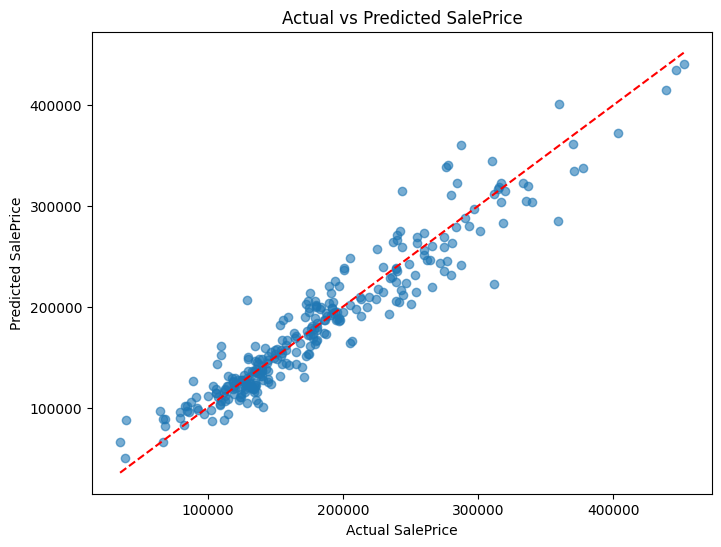

In [292]:
actual = np.expm1(Y_test)
predicted = np.expm1(y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(actual, predicted, alpha=0.6)

plt.plot([actual.min(), actual.max()],
         [actual.min(), actual.max()],
         'r--')

plt.xlabel('Actual SalePrice')
plt.ylabel('Predicted SalePrice')
plt.title('Actual vs Predicted SalePrice')

plt.show()

#### 4.2 Ridge Regression (L2)


In [293]:
alphas=[0.01, 0.1, 1, 10, 100]
rcv = linear_model.RidgeCV(alphas=alphas, cv=5)
rcv.fit(X_train, Y_train)
rcv_pred = rcv.predict(X_test)
print("Best Alpha: ",rcv.alpha_)
print("RMSE: ", metrics.root_mean_squared_error(Y_test, rcv_pred))
print("MAE: ", metrics.mean_absolute_error(Y_test, rcv_pred))
print("R^2 Score: ", metrics.r2_score(Y_test, rcv_pred))

Best Alpha:  0.01
RMSE:  0.13353659926217631
MAE:  0.09461584851468327
R^2 Score:  0.8942198448911352


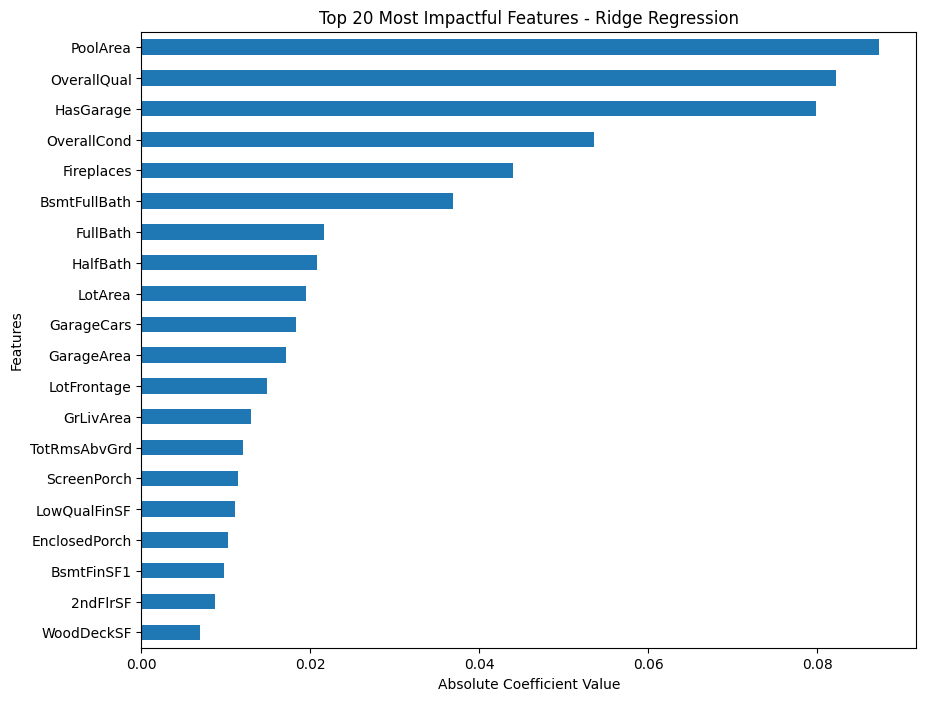

In [294]:
coefficients = pd.Series(rcv.coef_, index=X_train.columns)

top_20 = coefficients.sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 8))
top_20.sort_values().plot(kind='barh')

plt.xlabel('Absolute Coefficient Value')
plt.ylabel('Features')
plt.title('Top 20 Most Impactful Features - Ridge Regression')

plt.show()

#### Lasso Regression (L1)

In [295]:
alphas=[0.0001, 0.001, 0.01, 0.1, 1]
lcv = linear_model.LassoCV(alphas=alphas, cv=5, max_iter=10000)
lcv.fit(X_train, Y_train)
lcv_pred = lcv.predict(X_test)
print("Best Alpha: ",lcv.alpha_)
print("0-Coefficients : ",(lcv.coef_ == 0).sum())
print("RMSE: ", metrics.root_mean_squared_error(Y_test, lcv_pred))
print("MAE: ", metrics.mean_absolute_error(Y_test, lcv_pred))
print("R^2 Score: ", metrics.r2_score(Y_test, lcv_pred))

Best Alpha:  0.001
0-Coefficients :  9
RMSE:  0.13209539011034008
MAE:  0.09344368218580527
R^2 Score:  0.896490812613745


Lasso performed slightly better than Ridge because it had lower RMSE and MAE and higher R². It also set 9 coefficients to zero, making the model simpler.

------------------------------------------------------------------------------------------------------------------------------------

### Step 5: Advanced Models — Random Forest & XGBoost Regressor

------------------------------------------------------------------------------------------------------------------------------------

#### 5.1 Random Forest Regressor

In [296]:
rf=ensemble.RandomForestRegressor(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1)
rf.fit(X_train, Y_train)
rf_pred = rf.predict(X_test)
print("RMSE: ", metrics.root_mean_squared_error(Y_test, rf_pred))
print("MAE: ", metrics.mean_absolute_error(Y_test, rf_pred))
print("R^2 Score: ", metrics.r2_score(Y_test, rf_pred))

RMSE:  0.15040442033169704
MAE:  0.09828464062152119
R^2 Score:  0.8658085715473134


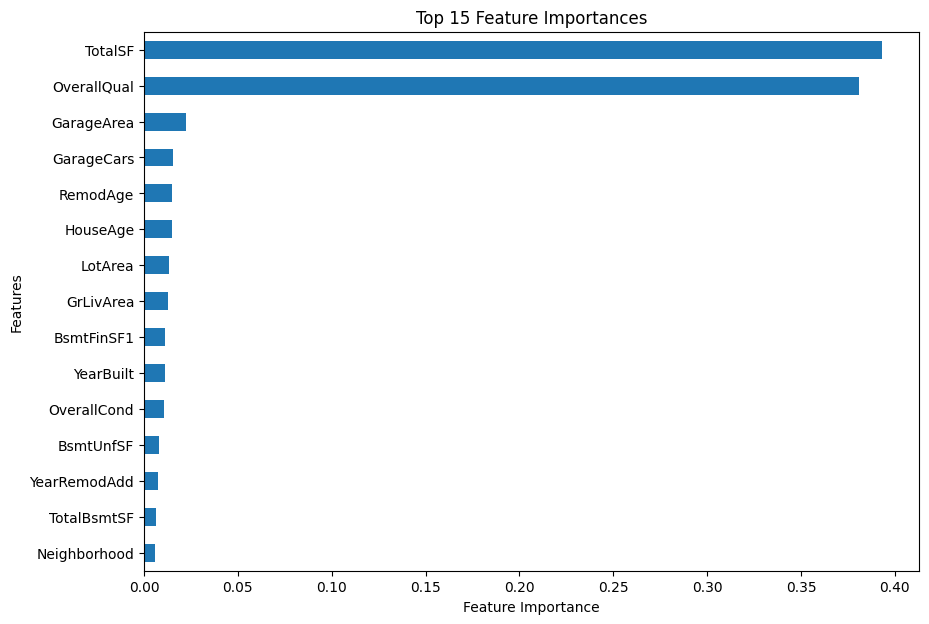

In [297]:
importances = pd.Series(rf.feature_importances_, index=X_train.columns)

top_15 = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top_15.sort_values().plot(kind='barh')

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances')

plt.show()

### 5.2 XGBoost Regressor

In [298]:
xgb=xgboost.XGBRegressor(n_estimators=500, learning_rate=0.05, max_depth=4, subsample=0.8, colsample_bytree=0.8, random_state=42)
xgb.fit(X_train, Y_train)
xgb_pred = xgb.predict(X_test)
print("RMSE: ", metrics.root_mean_squared_error(Y_test, xgb_pred))
print("MAE: ", metrics.mean_absolute_error(Y_test, xgb_pred))
print("R^2 Score: ", metrics.r2_score(Y_test, xgb_pred))

RMSE:  0.12981085525706945
MAE:  0.08549314303523696
R^2 Score:  0.9000401494658362


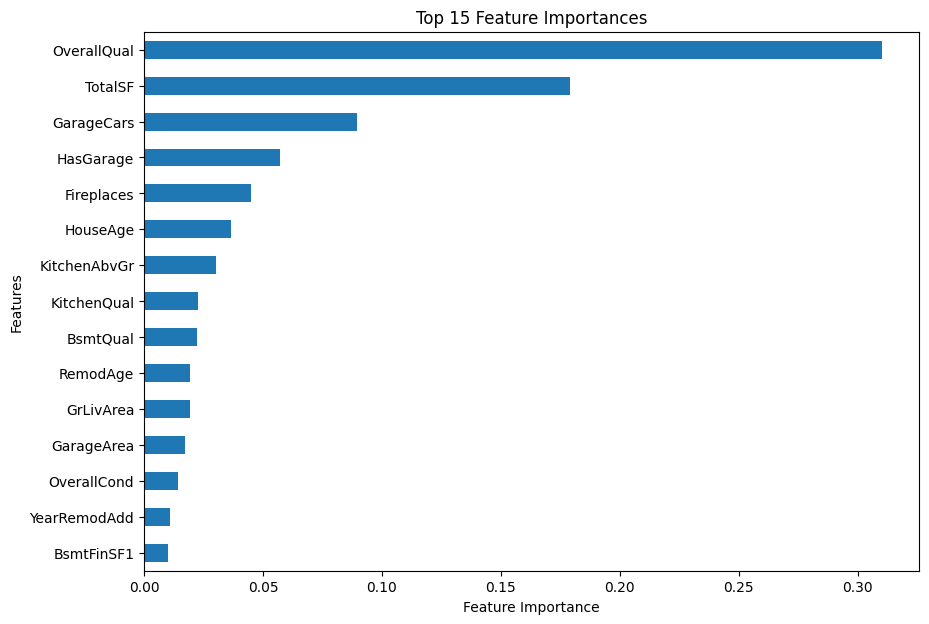

In [299]:
importances = pd.Series(xgb.feature_importances_, index=X_train.columns)

top_15_xgb = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 7))
top_15_xgb.sort_values().plot(kind='barh')

plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title('Top 15 Feature Importances')

plt.show()

#### 5.3 Cross-Validation (on best model so far)

In [300]:
cv = model_selection.KFold(n_splits=5, shuffle=True, random_state=42)

scores = model_selection.cross_val_score(
    rf,
    X_train,
    Y_train,
    cv=cv,
    scoring='neg_root_mean_squared_error'
)

print("Cross-Validation RMSE Scores: ", scores)
print("Mean STD RMSE: ", scores.std())

Cross-Validation RMSE Scores:  [-0.15652461 -0.13780733 -0.1269748  -0.12389336 -0.14388065]
Mean STD RMSE:  0.011816630725201891


#### 5.4 Hyperparameter Tuning

In [301]:
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [5, 10, 15, 20],
    'min_samples_split': [2, 5, 10]
}

random_search = model_selection.RandomizedSearchCV(
    rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    random_state=42
)

random_search.fit(X_train, Y_train)

print("Best Parameters:", random_search.best_params_)
print("Best CV RMSE:", -random_search.best_score_)

Best Parameters: {'n_estimators': 500, 'min_samples_split': 2, 'max_depth': 20}
Best CV RMSE: -0.8778904750116334


In [302]:
tuned_rf = random_search.best_estimator_

tuned_pred = tuned_rf.predict(X_test)

actual = np.expm1(Y_test)
predicted = np.expm1(tuned_pred)

print("Test RMSE:", metrics.root_mean_squared_error(actual, predicted))
print("Test MAE:", metrics.mean_absolute_error(actual, predicted))
print("Test R²:", metrics.r2_score(actual, predicted))

Test RMSE: 23880.98348053593
Test MAE: 16435.215945832864
Test R²: 0.8967542503470745


------------------------------------------------------------------------------------------------------------------------------------

### Step 6: Model Evaluation & Comparison

------------------------------------------------------------------------------------------------------------------------------------

In [303]:
compare_all_model = pd.DataFrame({

    'Model': ['Linear Regression', 'Ridge Regression', 'Lasso Regression',
              'Random Forest', 'XGBoost', 'Tuned Random Forest'],

    'RMSE': [
        metrics.root_mean_squared_error(Y_test, y_pred),
        metrics.root_mean_squared_error(Y_test, rcv_pred),
        metrics.root_mean_squared_error(Y_test, lcv_pred),
        metrics.root_mean_squared_error(Y_test, rf_pred),
        metrics.root_mean_squared_error(Y_test, xgb_pred),
        metrics.root_mean_squared_error(Y_test, tuned_pred)
    ],

    'MAE': [
        metrics.mean_absolute_error(Y_test, y_pred),
        metrics.mean_absolute_error(Y_test, rcv_pred),
        metrics.mean_absolute_error(Y_test, lcv_pred),
        metrics.mean_absolute_error(Y_test, rf_pred),
        metrics.mean_absolute_error(Y_test, xgb_pred),
        metrics.mean_absolute_error(Y_test, tuned_pred)
    ],

    'R^2 Score': [
        metrics.r2_score(Y_test, y_pred),
        metrics.r2_score(Y_test, rcv_pred),
        metrics.r2_score(Y_test, lcv_pred),
        metrics.r2_score(Y_test, rf_pred),
        metrics.r2_score(Y_test, xgb_pred),
        metrics.r2_score(Y_test, tuned_pred)
    ]

})

compare_all_model

,Model,RMSE,MAE,R^2 Score
0,Linear Regression,0.133613,0.094650,0.894098
1,Ridge Regression,0.133537,0.094616,0.894220
2,Lasso Regression,0.132095,0.093444,0.896491
3,Random Forest,0.150404,0.098285,0.865809
4,XGBoost,0.129811,0.085493,0.900040
5,Tuned Random Forest,0.149486,0.098076,0.867443


------------------------------------------------------------------------------------------------------------------------------------


### Step 7: Residual Analysis & Model Interpretation

------------------------------------------------------------------------------------------------------------------------------------


7.1 Residual Plots

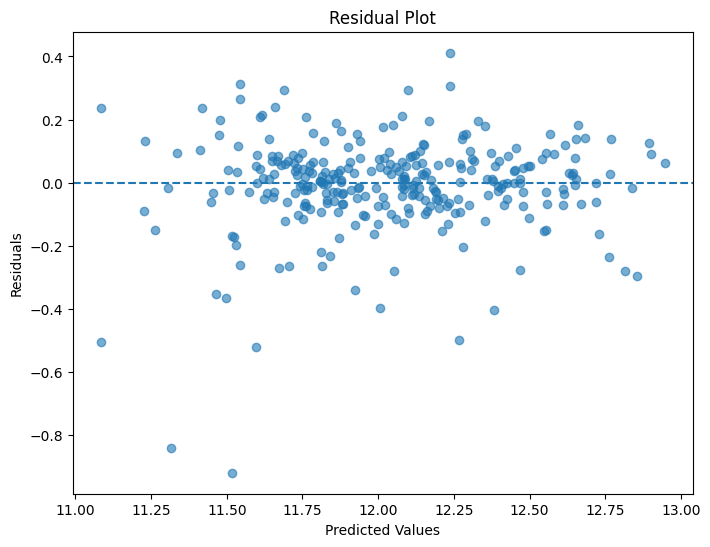

In [304]:
#Plot Residuals vs Fitted values for your best model. Are residuals randomly scattered (good) or show a pattern (bad)?

residuals = Y_test - tuned_pred

plt.figure(figsize=(8, 6))
plt.scatter(tuned_pred, residuals, alpha=0.6)

plt.axhline(y=0, linestyle='--')

plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')

plt.show()

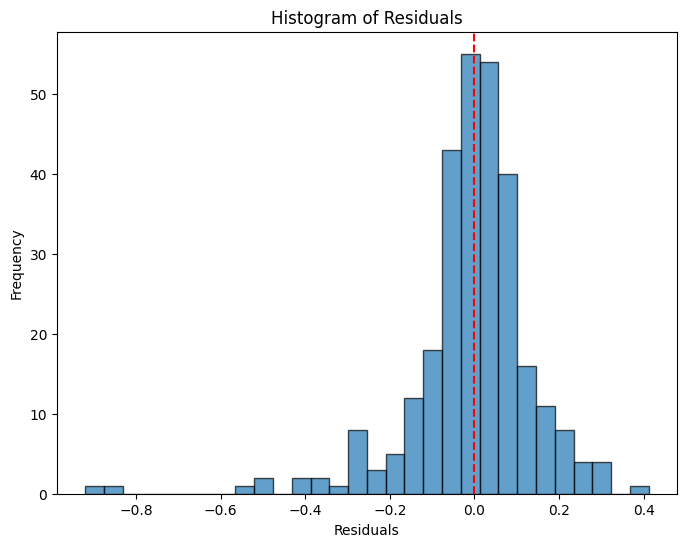

In [305]:
#Plot a histogram of residuals. Are they approximately normally distributed?

plt.figure(figsize=(8, 6))
plt.hist(residuals, bins=30, edgecolor='black', alpha=0.7)
plt.axvline(x=0, color='red', linestyle='--')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Histogram of Residuals')
plt.show()

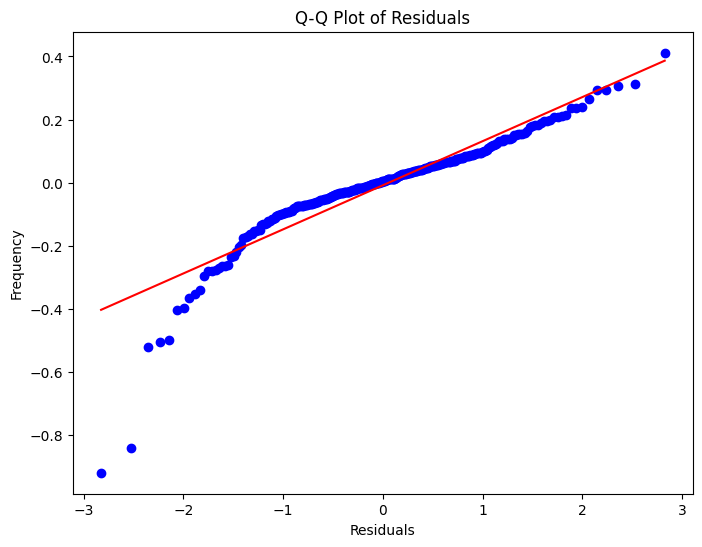

In [306]:
#Plot a Q-Q plot of residuals. Comment on any heavy tails.
plt.figure(figsize=(8, 6))
stats.probplot(residuals, dist="norm", plot=plt)
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Q-Q Plot of Residuals')
plt.show()


#### 7.2 Business Interpretation

In [307]:
#List the top 5 most impactful features from your best model.

importance = pd.Series(tuned_rf.feature_importances_, index=X_train.columns)
top_5 = importance.sort_values(ascending=False).head(5)

print(top_5)

TotalSF        0.387824
OverallQual    0.382382
GarageArea     0.021632
GarageCars     0.015239
HouseAge       0.014440
dtype: float64


In [314]:
X = df.drop('SalePrice', axis=1)
Y = np.log1p(df['SalePrice'])

X_train, X_test, Y_train, Y_test = model_selection.train_test_split(
    X, Y, test_size=0.2, random_state=42
)